<a href="https://colab.research.google.com/github/hj090/DACON_predict_14class/blob/dev_ym/stage1_stage2_%EC%B6%94%EB%A1%A0(07.13).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

stage1+stage2+추론(07_12).ipynb의 사본

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1zcX8cA5s9V483yhTLouY-zjCrxUz8vXH

In [ ]:
# 셀 A — numpy부터 먼저 정확히 고정 (이게 젤 먼저)
!pip install -q "numpy==1.26.4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 68.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires num

In [ ]:
# 셀 B — 나머지
!pip install -q "scipy==1.15.3" "threadpoolctl==3.6.0" "joblib==1.5.3" "scikit-learn==1.8.0"
!pip install -q "transformers==4.46.3"
!pip uninstall -y torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 49.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.2 MB/s eta 0:00:00
   

In [ ]:
# 셀 C — ONNX 관련 (원래 #0)
!pip install onnxmltools skl2onnx onnxruntime onnxconverter-common --break-system-packages -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 20.0 MB/s eta 0:00:00


# Stage1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##1. 라이브러리 불러오기

In [2]:
import csv
import json
import os

In [3]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import numpy as np
import re
import pandas as pd

In [4]:
# 예측 대상 14개 클래스 (Macro-F1 계산에 사용)
ALL_CLASSES = [
    "read_file", "grep_search", "list_directory", "glob_pattern",
    "edit_file", "write_file", "apply_patch",
    "run_bash", "run_tests", "lint_or_typecheck",
    "ask_user", "plan_task", "web_search", "respond_only",
]

##2. 데이터 불러오기

In [5]:
DATA_DIR = "/content/drive/MyDrive/nlp_competition/data" ### 임유미 수정

In [6]:
# train.jsonl: 한 줄 = 샘플 하나
samples = [json.loads(line)
           for line in open(os.path.join(DATA_DIR, "train.jsonl"), encoding="utf-8")
           if line.strip()]

In [7]:
# train_labels.csv: id -> action 매핑
labels = {row["id"]: row["action"]
          for row in csv.DictReader(open(os.path.join(DATA_DIR, "train_labels.csv"), encoding="utf-8"))}

In [8]:
# 입력 X = current_prompt, 정답 y = action
X = [s["current_prompt"] for s in samples]
y = [labels[s["id"]] for s in samples]
ids = [s["id"] for s in samples]

In [9]:
# id로 원본 샘플(session_meta 포함)을 바로 찾기 위한 딕셔너리
samples_by_id = {s["id"]: s for s in samples}

In [10]:
print("samples:", len(X), "| classes:", len(set(y)))

samples: 70000 | classes: 14


##3. 학습 / 검증 데이터 분할

In [11]:
X_train, X_val, y_train, y_val, train_ids, val_ids = train_test_split(
    X, y, ids, test_size=0.2, stratify=y, random_state=42,
)
print("train:", len(X_train), "| val:", len(X_val))

train: 56000 | val: 14000


In [12]:
# session meta 추가 연결
from sklearn.compose import ColumnTransformer

In [13]:
def extract_session_features(sample):
  s = samples_by_id[sample]

  meta = s.get("session_meta", {}) or {}
  ws = meta.get("workspace", {}) or {}
  lang_mix = ws.get("language_mix") or {}
  dom_lang, dom_ratio = max(lang_mix.items(), key=lambda kv: kv[1]) if lang_mix else ("none", 0.0)

  return {
    "language_pref": meta.get("language_pref", "unknown"),
    "last_ci_status": ws.get("last_ci_status", "none"),
    "git_dirty": str(ws.get("git_dirty", False)),
    "user_tier": meta.get("user_tier", "unknown"),
    "turn_index": meta.get("turn_index", 0),
    "budget_tokens_remaining_log": np.log1p(meta.get("budget_tokens_remaining", 0)),
    "loc_log": np.log1p(ws.get("loc", 0)),
    "n_open_files": len(ws.get("open_files") or []),
    "dominant_code_lang": dom_lang,
    "dominant_code_ratio": dom_ratio,
    "n_code_langs": len(lang_mix),
    "elapsed_session_sec_log": np.log1p(meta.get("elapsed_session_sec", 0)),
}

In [14]:
# train_ids / val_ids 순서 그대로 매핑
session_train_df = pd.DataFrame([extract_session_features(i) for i in train_ids])
session_val_df = pd.DataFrame([extract_session_features(i) for i in val_ids])

In [15]:
def extract_history_features(sample_id):
    s = samples_by_id[sample_id]
    history = s.get("history", []) or []

    # 최근 assistant_action 찾기 (뒤에서부터 탐색)
    last_action = None
    turns_since = 0
    for turn in reversed(history):
        if turn.get("role") == "assistant_action":
            last_action = turn
            break
        turns_since += 1   # user 턴을 지나칠 때마다 카운트

    if last_action is None:
        # 아직 action이 한 번도 없었던 경우 (대화 시작 단계)
        return {
            "last_action_name": "none",
            "last_action_result_status": "none",
            "n_actions_so_far": 0,
            "last_action_ext": "none",
            "turns_since_last_action": len(history),
        }

    # 결과 요약에서 성공/실패/에러 신호 추출
    result_summary = (last_action.get("result_summary") or "").lower()
    if re.search(r"fail|error|exception|traceback", result_summary):
        result_status = "fail"
    elif re.search(r"\bok\b|success|passed", result_summary):
        result_status = "ok"
    else:
        result_status = "unknown"

    # 파일 확장자 추출 (args.path가 있을 경우)
    path = (last_action.get("args") or {}).get("path", "")
    ext_match = re.search(r"\.(\w+)$", path)
    ext = ext_match.group(1) if ext_match else "none"

    # 전체 action 개수 카운트
    n_actions = sum(1 for turn in history if turn.get("role") == "assistant_action")

    return {
        "last_action_name": last_action.get("name", "none"),
        "last_action_result_status": result_status,
        "n_actions_so_far": n_actions,
        "last_action_ext": ext,
        "turns_since_last_action": turns_since,
    }

history_train_df = pd.DataFrame([extract_history_features(i) for i in train_ids])
history_val_df = pd.DataFrame([extract_history_features(i) for i in val_ids])

In [16]:
# 원-핫 인코딩 (학습 데이터로 fit, 검증은 transform만)
CATEGORICAL_COLS = ["language_pref", "last_ci_status", "git_dirty", "user_tier", "dominant_code_lang",
                    "last_action_name", "last_action_result_status", "last_action_ext"]
NUMERIC_COLS = ["turn_index", "budget_tokens_remaining_log", "loc_log", "n_open_files", "dominant_code_ratio", "n_code_langs", "elapsed_session_sec_log",
                "n_actions_so_far", "turns_since_last_action"]

# session_train_df와 history_train_df 합치기
combined_train_df = pd.concat([session_train_df, history_train_df], axis=1)
combined_val_df = pd.concat([session_val_df, history_val_df], axis=1)

combined_encoder = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_COLS),
    ("num", StandardScaler(), NUMERIC_COLS),   # 숫자는 변환 없이 그대로 통과
])

combined_train_enc = combined_encoder.fit_transform(combined_train_df)
combined_val_enc = combined_encoder.transform(combined_val_df)

##4. 모델 정의와 학습 (TF-IDF + LightGBM)

In [71]:
#규칙 기반 피처 클래스
class RuleFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self   # 학습할 게 없으니 그냥 자기 자신 반환

    def transform(self, X):
        return np.array([self._extract(text) for text in X])

    def _extract(self, text):
        return [
            1 if re.search(r'\b(read|열어|읽어)\b', text, re.I) else 0,
            1 if re.search(r'(grep|검색|찾아).*(코드|텍스트|패턴)', text, re.I) else 0,
            1 if re.search(r'(폴더|디렉토리|directory).*(뭐|목록|구조)', text, re.I) else 0,
            1 if re.search(r'\*\.\w+|글롭|glob|확장자', text, re.I) else 0,
            1 if re.search(r'(수정|고쳐|바꿔|edit)', text, re.I) else 0,
            1 if re.search(r'(새로|생성|만들어|write).*(파일|코드)', text, re.I) else 0,
            1 if re.search(r'(diff|patch|패치|변경사항)', text, re.I) else 0,
            1 if re.search(r'(셸|shell|bash|명령어|터미널)', text, re.I) else 0,
            1 if re.search(r'(테스트|test).*(실행|돌려|run)', text, re.I) else 0,
            1 if re.search(r'(린트|lint|타입체크|맞춤법)', text, re.I) else 0,
            1 if '?' in text else 0,
            1 if re.search(r'(계획|설계|plan)', text, re.I) else 0,
            1 if re.search(r'(웹|인터넷|구글|web)', text, re.I) else 0,
            1 if re.search(r'[\w\-]+\.[A-Za-z0-9]{1,6}\b|[\w\-]+/[\w\-./]+', text) else 0,  # 임유미 추가: 명시적 파일 경로/확장자 언급 여부
            len(text),
            len(re.findall(r'[a-zA-Z]', text)),
        ]

rule_extractor = RuleFeatureExtractor()
rule_features_train = rule_extractor.transform(X_train)
rule_features_val = rule_extractor.transform(X_val)

In [18]:
#LightGBM의 성능평가지표를 Macro-F1 직접 만들기

In [19]:
def macro_f1_eval(y_true, y_pred_proba):
    y_pred = y_pred_proba.reshape(len(y_true), -1).argmax(axis=1)
    f1 = f1_score(y_true, y_pred, average="macro")
    return "macro_f1", f1, True   # True = "높을수록 좋음"

In [20]:
#1. TF-IDF
tfidf_chi2 = Pipeline([
    #1-1) TF-IDF
    ("tfidf", TfidfVectorizer(ngram_range=(1,3), min_df=2, max_features=80_000,
                                sublinear_tf=True, lowercase=True)),
    #1-2) chi2 피처 선택
    ("chi2", SelectKBest(chi2, k=30_000)),
])

# 가지2: 규칙 기반 피처
rule = RuleFeatureExtractor()

# 두 갈래를 FeatureUnion으로 결합
vectorizer_pipe = FeatureUnion([
    ("tfidf_chi2", tfidf_chi2),
    ("rule_features", rule),
])

vectorizer = vectorizer_pipe
X_train_vec = vectorizer.fit_transform(X_train, y_train)
X_val_vec = vectorizer.transform(X_val)

#session meta, history 피쳐 결합
X_train_final = hstack([X_train_vec, combined_train_enc])
X_val_final = hstack([X_val_vec, combined_val_enc])

In [72]:
#2. LightGBM
clf = lgb.LGBMClassifier(n_estimators=400, num_leaves=100, min_child_samples=10, learning_rate=0.05,
                            objective="multiclass", class_weight="balanced", force_row_wise=True, random_state=42)
best_clf = clf

best_clf.fit(
    X_train_final, y_train,
    eval_set=[(X_val_final, y_val)],
    eval_metric=macro_f1_eval,
    callbacks=[lgb.early_stopping(stopping_rounds=150)],
)

Exception ignored on calling ctypes callback function: <function _log_callback at 0x7c1e38b38360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


Total Bins 213233
[LightGBM] [Info] Number of data points in the train set: 56000, number of used features: 10524
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Info] Start training from score -2.639057
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 150 

KeyboardInterrupt: 

In [22]:
tfidf_probs_train = best_clf.predict_proba(X_train_final)   # 학습셋 확률 (가중치 튜닝용)
tfidf_probs_val = best_clf.predict_proba(X_val_final)       # 검증셋 확률

rule_only_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
rule_only_clf.fit(rule_features_train, y_train)
rule_probs_train = rule_only_clf.predict_proba(rule_features_train)
rule_probs_val = rule_only_clf.predict_proba(rule_features_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [23]:
best_w = 1.0
best_threshold = 0.9

def route_by_confidence(ids, tfidf_probs, rule_probs, classes, w=best_w, threshold=best_threshold): ### 임유미 수정 (인자로 classes를 받도록 함수 정의부 수정)
    """
    Stage1 앙상블 예측 확률을 보고, 확신도에 따라 라우팅하는 함수

    Parameters
    ----------
    ids : list
        각 샘플의 고유 id
    tfidf_probs : np.ndarray (샘플수, 14)
        TF-IDF+LightGBM 모델의 확률
    rule_probs : np.ndarray (샘플수, 14)
        규칙피처+LogReg 모델의 확률
    classes: probs의 각 컬럼이 어떤 클래스를 의미하는지 알려주는 배열
        (반드시 predict_proba를 만든 모델의 .classes_ 를 그대로 넘길 것) ### 임유미 추가
    w : float
        TF-IDF 쪽 가중치
    threshold : float
        이 값 이상이면 Stage1에서 바로 확정

    Returns
    -------
    stage1_results : dict {id: action}
        확신도 높아서 Stage1에서 바로 결정된 것들
    stage2_input_ids : list
        확신도 낮아서 Stage2로 넘겨야 하는 id 목록
    stage2_probs : np.ndarray
        Stage2로 넘어가는 샘플들의 Stage1 확률 분포 (best_clf.predict_proba(X_vec) 결과)
    """
    ensemble_probs = w * tfidf_probs + (1 - w) * rule_probs
    max_conf = ensemble_probs.max(axis=1)      # 각 샘플의 "가장 높은 확률"
    pred_idx = ensemble_probs.argmax(axis=1)   # 그 확률에 해당하는 클래스 인덱스

    stage1_results = {}
    stage2_input_ids = []
    stage2_probs_list = []

    for sample_id, conf, idx, prob_row in zip(ids, max_conf, pred_idx, ensemble_probs):
        if conf >= threshold:
            #확신도 높음 → 확정
            stage1_results[sample_id] = classes[idx]   ### 임유미: ALL_CLASSES → classes로 변경
        else:
            #확신도 낮음 → Stage2로
            stage2_input_ids.append(sample_id)
            stage2_probs_list.append(prob_row)

    stage2_probs = np.array(stage2_probs_list) if stage2_probs_list else np.empty((0, len(ALL_CLASSES)))

    return stage1_results, stage2_input_ids, stage2_probs


In [24]:
#stage2 들어갈 데이터 받는 예시 코드
stage1_results, stage2_input_ids, stage2_probs = route_by_confidence(
    ids=val_ids,
    tfidf_probs=tfidf_probs_val,
    rule_probs=rule_probs_val,
    classes=best_clf.classes_,   ### 임유미 추가
)

print(f"Stage1에서 확정된 샘플 수: {len(stage1_results)}")
print(f"Stage2로 넘어가는 샘플 수: {len(stage2_input_ids)}")

Stage1에서 확정된 샘플 수: 2933
Stage2로 넘어가는 샘플 수: 11067


In [25]:
# 확정된 샘플들(Stage1에서 끝난 것들)만 따로 정확도 확인
ensemble_probs_val = best_w * tfidf_probs_val + (1-best_w) * rule_probs_val
max_conf = ensemble_probs_val.max(axis=1)
pred_idx = ensemble_probs_val.argmax(axis=1)
pred_labels = np.array([best_clf.classes_[i] for i in pred_idx])

confirmed_mask = max_conf >= best_threshold

confirmed_acc = (pred_labels[confirmed_mask] == np.array(y_val)[confirmed_mask]).mean()
print(f"✅ 확정 샘플 수: {confirmed_mask.sum()}")
print(f"🎯 확정 샘플 중 정확도: {confirmed_acc:.4f}")

✅ 확정 샘플 수: 2933
🎯 확정 샘플 중 정확도: 0.9587


##5. Stage1 검증 (Macro-F1)

In [26]:
ensemble_pred = np.array([best_clf.classes_[i] for i in ensemble_probs_val.argmax(axis=1)])
macro_f1 = f1_score(y_val, ensemble_pred, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"Validation Macro-F1: {macro_f1:.4f}")

Validation Macro-F1: 0.5836


# Stage2

##1. 라이브러리 정의

In [27]:
!pip uninstall -y torchcodec -q

In [28]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

## 2. Stage2 데이터셋 구성

In [29]:
def build_stage2_input_text(sample, history_turns=3):
    history = sample.get("history", []) or []
    hist_text = "\n".join(str(turn) for turn in history[-history_turns:])
    return f"{hist_text}\n{sample.get('current_prompt', '')}".strip()

In [31]:
def build_stage2_dataset(stage2_ids, stage2_probs, samples_by_id, labels, session_encoder, history_turns=3):
    """
    stage2_ids/stage2_probs: route_by_confidence가 넘긴 것 그대로 (stage2_probs는 앙상블 확률)
    session_encoder: Stage1에서 이미 fit된 ColumnTransformer (train 기준) — transform만 함
    """
    texts, y_stage2 = [], []
    for sid in stage2_ids:
        s = samples_by_id[sid]
        texts.append(build_stage2_input_text(s, history_turns))
        y_stage2.append(labels[sid])

    # ---- session_meta 인코딩 (Stage1의 extract_session_features 재사용) ----
    session_df = pd.DataFrame([extract_session_features(sid) for sid in stage2_ids])
    history_df = pd.DataFrame([extract_history_features(sid) for sid in stage2_ids])   ### 윤서영 추가
    combined_df = pd.concat(   ### 윤서영 추가
        [session_df.reset_index(drop=True), history_df.reset_index(drop=True)], axis=1
    )
    session_enc = session_encoder.transform(combined_df)   ### 윤서영 수정
    if hasattr(session_enc, "toarray"):   # ColumnTransformer 결과가 sparse일 수 있음
        session_enc = session_enc.toarray()

    return texts, y_stage2, np.array(stage2_probs), session_enc.astype(np.float32)

In [32]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [33]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [34]:
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 3. history_turns 튜닝

history_turns 후보별로 데이터셋을 다시 만들고, 기본 C(=1.0)의 LogisticRegression으로
OOF Macro-F1을 비교해서 가장 좋은 history_turns를 고른다.
(MiniLM 인코딩을 후보 수만큼 반복하므로 후보가 많을수록 시간이 늘어남 — 필요시 후보 축소)

In [46]:
HISTORY_TURNS_CANDIDATES = [1, 2, 3,4,5]

In [47]:
best_ht, best_ht_f1, best_bundle = None, -1.0, None

In [48]:
for ht in HISTORY_TURNS_CANDIDATES:
    X_text_ht, y_ht, probs_ht, sess_ht = build_stage2_dataset(
        stage2_input_ids, stage2_probs, samples_by_id, labels, combined_encoder,
        history_turns=ht,
    )
    emb_ht = embedder.encode(X_text_ht, show_progress_bar=False)
    feat_ht = np.hstack([emb_ht, probs_ht, sess_ht])
    y_arr_ht = np.array(y_ht)

    oof_ht = np.empty(len(y_arr_ht), dtype=object)
    for train_idx, val_idx in skf.split(feat_ht, y_arr_ht):
        clf_ht = LogisticRegression(max_iter=1000, class_weight="balanced")
        clf_ht.fit(feat_ht[train_idx], y_arr_ht[train_idx])
        oof_ht[val_idx] = clf_ht.predict(feat_ht[val_idx])

    f1_ht = f1_score(y_arr_ht, oof_ht, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[history_turns={ht}] Macro-F1 (OOF, C=default): {f1_ht:.4f}")

    if f1_ht > best_ht_f1:
        best_ht_f1 = f1_ht
        best_ht = ht
        best_bundle = (X_text_ht, y_ht, probs_ht, sess_ht, emb_ht, feat_ht)

print(f"\n선택된 history_turns = {best_ht} (Macro-F1={best_ht_f1:.4f})")


[history_turns=1] Macro-F1 (OOF, C=default): 0.4371
[history_turns=2] Macro-F1 (OOF, C=default): 0.4420
[history_turns=3] Macro-F1 (OOF, C=default): 0.5028
[history_turns=4] Macro-F1 (OOF, C=default): 0.5020
[history_turns=5] Macro-F1 (OOF, C=default): 0.4632

선택된 history_turns = 3 (Macro-F1=0.5028)


In [50]:
# 이후 코드는 최적 history_turns로 만든 데이터셋을 그대로 사용
X_stage2_text, y_stage2, stage1_probs_stage2, session_stage2_enc, emb_all, feat_all = best_bundle
y_stage2_arr = np.array(y_stage2)

print(f"Stage2 학습 후보: {len(X_stage2_text)}건")
print(f"session_meta 인코딩 shape: {session_stage2_enc.shape}")
print(pd.Series(y_stage2).value_counts())
print("session_stage2_enc shape:", session_stage2_enc.shape)
print(combined_encoder.get_feature_names_out())  # 'num__elapsed_session_sec_log' 포함 확인

Stage2 학습 후보: 11067건
session_meta 인코딩 shape: (11067, 75)
grep_search          1980
read_file            1850
edit_file            1436
glob_pattern         1056
list_directory        865
run_tests             801
run_bash              781
apply_patch           667
ask_user              487
plan_task             471
lint_or_typecheck     406
web_search            240
write_file             20
respond_only            7
Name: count, dtype: int64
session_stage2_enc shape: (11067, 75)
['cat__language_pref_en' 'cat__language_pref_ko'
 'cat__language_pref_mixed' 'cat__last_ci_status_failed'
 'cat__last_ci_status_none' 'cat__last_ci_status_passed'
 'cat__git_dirty_False' 'cat__git_dirty_True' 'cat__user_tier_enterprise'
 'cat__user_tier_free' 'cat__user_tier_pro' 'cat__dominant_code_lang_go'
 'cat__dominant_code_lang_java' 'cat__dominant_code_lang_py'
 'cat__dominant_code_lang_rs' 'cat__dominant_code_lang_ts'
 'cat__dominant_code_lang_tsx' 'cat__dominant_code_lang_vue'
 'cat__dominant_code_lan

## 3-1. Stage2에 어휘 규칙 피처(rule_features) + 경로 언급 피처 추가

In [91]:

"""## 3-1. Stage2에 어휘 규칙 피처(rule_features) + 경로 언급 피처 추가

read_file / grep_search / list_directory / glob_pattern 4개 클래스가 서로 혼동되는 문제 분석 결과,
"열어/보여줘 + 명시적 파일명" 같은 어휘 신호를 Stage2가 전혀 못 쓰고 있는 게 확인됨.
Stage1에서 이미 쓰던 RuleFeatureExtractor(정규식 15개 + 신규 경로/확장자 언급 피처 1개, 총 16개)를
Stage2 텍스트(X_stage2_text)에도 적용해서 feat_all에 추가한다.
rule_features는 이진 플래그 위주지만 len(text), 영문자 수처럼 스케일이 다른 값도 섞여 있어
LogisticRegression에 넣기 전에 StandardScaler로 스케일링한다.
"""

from sklearn.preprocessing import StandardScaler

rule_features_stage2 = rule_extractor.transform(X_stage2_text)  # (n_samples, 16)

stage2_rule_scaler = StandardScaler()
rule_features_stage2_scaled = stage2_rule_scaler.fit_transform(rule_features_stage2)

In [92]:
"""## 3-1. Stage2에 어휘 규칙 피처(rule_features) 추가 — current_prompt 기준

history+prompt 전체 텍스트에 rule_features를 적용하면 과거 턴의 키워드가 섞여
신호가 흐려짐(-0.0059 확인됨). current_prompt에만 적용한 버전이 가장 좋았으므로(+0.0056)
이걸 최종 채택.
"""

current_prompt_texts = [samples_by_id[sid].get("current_prompt", "") for sid in stage2_input_ids]
rule_features_stage2 = rule_extractor.transform(current_prompt_texts)

stage2_rule_scaler = StandardScaler()
rule_features_stage2_scaled = stage2_rule_scaler.fit_transform(rule_features_stage2)

feat_all = np.hstack([emb_all, stage1_probs_stage2, session_stage2_enc, rule_features_stage2_scaled])
print("rule_features_stage2 shape:", rule_features_stage2.shape)
print("feat_all shape (rule_features 추가 후):", feat_all.shape)

rule_features_stage2 shape: (11067, 16)
feat_all shape (rule_features 추가 후): (11067, 489)


## 4. GridSearchCV로 C 튜닝

최적 history_turns로 고정한 feat_all / y_stage2_arr 기준으로 C를 탐색한다.

선택된 C = 0.5337 (CV Macro-F1=0.5011)
         C  Macro-F1 (mean)  Macro-F1 (std)
  0.001000         0.250190        0.004922
  0.002848         0.323302        0.007563
  0.008111         0.398132        0.006383
  0.023101         0.454452        0.009535
  0.065793         0.480203        0.011403
  0.187382         0.495849        0.015184
  0.533670         0.501103        0.011586
  1.519911         0.499948        0.022580
  4.328761         0.490721        0.026036
 12.328467         0.483517        0.025580
 35.111917         0.470015        0.028143
100.000000         0.460495        0.026998


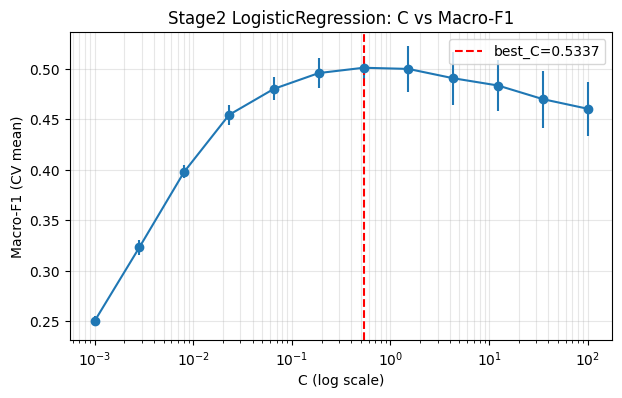

In [93]:
import numpy as np
import pandas as pd

param_grid = {
    "C": np.logspace(-3, 2, 12),   # 0.001 ~ 100, 로그스케일 12개 지점
}
gs = GridSearchCV(
    LogisticRegression(max_iter=2000, class_weight="balanced"),
    param_grid,
    scoring="f1_macro",
    cv=skf,
    n_jobs=-1,
)
gs.fit(feat_all, y_stage2_arr)

best_C = gs.best_params_["C"]
print(f"선택된 C = {best_C:.4g} (CV Macro-F1={gs.best_score_:.4f})")

# ---- C별 Macro-F1 표로 확인 ----
cv_results = pd.DataFrame(gs.cv_results_)
c_scores = cv_results[["param_C", "mean_test_score", "std_test_score"]].copy()
c_scores.columns = ["C", "Macro-F1 (mean)", "Macro-F1 (std)"]
c_scores = c_scores.sort_values("C").reset_index(drop=True)
print(c_scores.to_string(index=False))

# ---- 그래프로도 확인 ----
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.errorbar(c_scores["C"], c_scores["Macro-F1 (mean)"], yerr=c_scores["Macro-F1 (std)"], marker="o")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Macro-F1 (CV mean)")
plt.title("Stage2 LogisticRegression: C vs Macro-F1")
plt.axvline(best_C, color="red", linestyle="--", label=f"best_C={best_C:.4g}")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

##5. 분류 헤드 (Fold 앙상블: soft-voting으로 OOF 예측 생성)

기존에는 fold별로 학습한 head_fold를 predict()만 하고 버렸는데,
여기서는 fold별 확률(predict_proba)을 저장해서 평균(soft voting)한 뒤 argmax로 예측한다.
fold_models 리스트는 저장 용량이 커지므로(head 5개), 기본적으로는 OOF 평가에만 사용하고
실제 배포용 모델은 아래에서 전체 데이터로 재학습한 head_final 하나만 저장한다.

In [94]:
fold_models = []
oof_proba = np.zeros((len(y_stage2_arr), len(ALL_CLASSES)))

In [95]:
for fold_idx, (train_idx, val_idx) in enumerate(skf.split(feat_all, y_stage2_arr)):
    head_fold = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
    head_fold.fit(feat_all[train_idx], y_stage2_arr[train_idx])

    proba = head_fold.predict_proba(feat_all[val_idx])
    for j, c in enumerate(head_fold.classes_):
        col = ALL_CLASSES.index(c)
        oof_proba[val_idx, col] = proba[:, j]

    fold_models.append(head_fold)
    print(f"Fold {fold_idx+1}/{n_splits} 완료")

oof_preds = np.array(ALL_CLASSES)[oof_proba.argmax(axis=1)]
stage2_oof_dict = dict(zip(stage2_input_ids, oof_preds))

Fold 1/5 완료
Fold 2/5 완료
Fold 3/5 완료
Fold 4/5 완료
Fold 5/5 완료


In [96]:
# ---- 전체 stage2 데이터로 최종 head 학습 (best_C 반영, 배포용) ----
head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
head_final.fit(feat_all, y_stage2_arr)

LogisticRegression(C=np.float64(0.5336699231206307), class_weight='balanced',
                   max_iter=1000)

In [97]:
# (선택) fold 앙상블을 실제 추론에도 쓰고 싶다면 아래처럼 fold_models 5개를 저장해서
# 추론 시 predict_proba 평균을 내면 된다. 다만 저장 용량이 head_final 하나 대비 5배가 되므로
# 1GB 용량 제약을 먼저 확인할 것.
# joblib.dump(fold_models, "./model/stage2_head_folds.pkl", compress=3)

## 6. (선택) 임베딩 모델 부분 파인튜닝

시간/자원 여유가 있을 때만 실행. DO_FINETUNE=True로 바꾸면 같은 클래스(action) 라벨을 가진
Stage2 텍스트끼리는 가깝게, 다른 클래스는 멀게 학습하는 대조학습(CosineSimilarityLoss)으로
MiniLM을 몇 epoch만 가볍게 파인튜닝한다. 결과가 좋을 때만 embedder를 교체해서 이어서 쓸 것
(용량/추론시간이 늘어나지 않는지 꼭 재확인 — 파인튜닝해도 아키텍처/파라미터 수는 동일하므로
1GB·10분 제약에는 영향 없음).

In [98]:
DO_FINETUNE = True  # 필요할 때 True로 변경

In [99]:
if DO_FINETUNE:
    import random
    from sentence_transformers import InputExample, losses
    from torch.utils.data import DataLoader

    random.seed(42)

    # 같은 클래스면 유사도 1, 다른 클래스면 0으로 학습 쌍 생성 (클래스당 과도한 조합 방지 위해 샘플링)
    by_class = {}
    for text, label in zip(X_stage2_text, y_stage2):
        by_class.setdefault(label, []).append(text)

    train_examples = []
    N_POS_PER_CLASS = 300
    N_NEG_PAIRS = 1500

    for label, texts in by_class.items():
        if len(texts) < 2:
            continue
        for _ in range(min(N_POS_PER_CLASS, len(texts) * 2)):
            a, b = random.sample(texts, 2)
            train_examples.append(InputExample(texts=[a, b], label=1.0))

    all_labels = list(by_class.keys())
    for _ in range(N_NEG_PAIRS):
        l1, l2 = random.sample(all_labels, 2)
        a = random.choice(by_class[l1])
        b = random.choice(by_class[l2])
        train_examples.append(InputExample(texts=[a, b], label=0.0))

    random.shuffle(train_examples)
    print(f"파인튜닝 학습 쌍: {len(train_examples)}개")

    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
    train_loss = losses.CosineSimilarityLoss(model=embedder)

    embedder.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=1,               # 과적합/시간 고려해 1~2 epoch 정도만
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True,
    )

    # 파인튜닝된 embedder로 임베딩 재계산 + head 재학습해서 개선 여부 확인
    emb_all_ft = embedder.encode(X_stage2_text, show_progress_bar=True)
    feat_all_ft = np.hstack([emb_all_ft, stage1_probs_stage2, session_stage2_enc])

    oof_preds_ft = np.empty(len(y_stage2_arr), dtype=object)
    for train_idx, val_idx in skf.split(feat_all_ft, y_stage2_arr):
        clf_ft = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
        clf_ft.fit(feat_all_ft[train_idx], y_stage2_arr[train_idx])
        oof_preds_ft[val_idx] = clf_ft.predict(feat_all_ft[val_idx])

    f1_ft = f1_score(y_stage2_arr, oof_preds_ft, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[파인튜닝 후] Stage2 Macro-F1 (OOF): {f1_ft:.4f}  (파인튜닝 전 기준과 비교해서 개선됐을 때만 채택)")

    # 개선됐을 경우에만 아래 주석 해제해서 정식 반영
    # emb_all, feat_all = emb_all_ft, feat_all_ft
    # head_final = LogisticRegression(max_iter=1000, class_weight="balanced", C=best_C)
    # head_final.fit(feat_all, y_stage2_arr)

파인튜닝 학습 쌍: 5154개


Step,Training Loss


Batches:   0%|          | 0/346 [00:00<?, ?it/s]

[파인튜닝 후] Stage2 Macro-F1 (OOF): 0.5416  (파인튜닝 전 기준과 비교해서 개선됐을 때만 채택)


#Stage2 임베더 오프라인 저장 (minilm_local 생성)

In [ ]:
MINILM_SAVE_PATH = "/content/drive/MyDrive/nlp_competition_4/model/minilm_local"
os.makedirs(os.path.dirname(MINILM_SAVE_PATH), exist_ok=True)

In [ ]:
# 셀 35에서 이미 로드/사용된 embedder를 그대로 저장 (재다운로드 X, 가중치 동일성 보장)
embedder.save(MINILM_SAVE_PATH)

In [ ]:
print("저장 완료:", MINILM_SAVE_PATH)
print("저장된 파일 목록:", os.listdir(MINILM_SAVE_PATH))

##7. Stage2 Macro-F1 측정

In [102]:
stage2_macro_f1 = f1_score(y_stage2_arr, oof_preds, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"Stage2 단독 Validation Macro-F1 (OOF): {stage2_macro_f1:.4f}")
print(classification_report(y_stage2_arr, oof_preds, labels=ALL_CLASSES, zero_division=0))

Stage2 단독 Validation Macro-F1 (OOF): 0.5063
                   precision    recall  f1-score   support

        read_file       0.49      0.36      0.42      1850
      grep_search       0.59      0.49      0.53      1980
   list_directory       0.35      0.62      0.45       865
     glob_pattern       0.53      0.55      0.54      1056
        edit_file       0.79      0.71      0.75      1436
       write_file       0.17      0.30      0.22        20
      apply_patch       0.54      0.67      0.59       667
         run_bash       0.65      0.60      0.62       781
        run_tests       0.62      0.64      0.63       801
lint_or_typecheck       0.45      0.57      0.50       406
         ask_user       0.52      0.49      0.51       487
        plan_task       0.53      0.49      0.51       471
       web_search       0.44      0.61      0.51       240
     respond_only       0.25      0.43      0.32         7

         accuracy                           0.55     11067
        ma

## 혼동행렬 확인

In [101]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_stage2_arr, oof_preds, labels=ALL_CLASSES)
cm_df = pd.DataFrame(cm, index=ALL_CLASSES, columns=ALL_CLASSES)

target = ["read_file", "grep_search", "list_directory", "glob_pattern"]
print(cm_df.loc[target, target])
print()
# 이 4개 클래스가 서로한테 오답을 얼마나 주는지 vs 다른 클래스로 새는지 비교
print(cm_df.loc[target].sum(axis=1))       # 실제 개수
print(cm_df.loc[target, target].sum(axis=1))  # 이 4개 그룹 내에서 소비된 오답 수

mask = (np.array(y_stage2_arr) == "read_file") & (oof_preds == "list_directory")
confused_ids = np.array(stage2_input_ids)[mask]
for sid in confused_ids[:15]:
    print(sid, "→", build_stage2_input_text(samples_by_id[sid], history_turns=3)[-200:])

                read_file  grep_search  list_directory  glob_pattern
read_file             670          378             455           236
grep_search           382          964             310           185
list_directory        126          110             532            56
glob_pattern          153          116             154           578

read_file         1850
grep_search       1980
list_directory     865
glob_pattern      1056
dtype: int64
read_file         1739
grep_search       1841
list_directory     824
glob_pattern      1001
dtype: int64
sess_au_546812_005-step_03 → 듯. 인증 관련 파일들부터 추려줘'}
{'role': 'assistant_action', 'name': 'glob_pattern', 'args': {'pattern': 'src/**/*auth*.py'}, 'result_summary': "1 files matched 'src/**/*auth*.py'"}
auth.py 하나뿐이네. refresh 핸들러 보자
sess_au_932586_009-step_01 → ci 워크플로가 단계가 너무 중구난방이라 정리하고 싶어. 일단 ci.yml 내용 보여줘
sess_sim_20260522_008433-step_02 → '모델 쪽 테스트 깨진 거 없나 확인'}
{'role': 'assistant_action', 'name': 'run_bash', 'args': {'cmd': 'node script.

#Stage1+Stage2 전체 Macro-F1 측정

In [82]:
##5. Stage1 + Stage2 통합 Macro-F1 (전체 val_ids 커버)

final_preds = dict(stage1_results)          # stage1 확정분 1,643건
final_preds.update(stage2_oof_dict)         # stage2 전체 12,357건 (OOF 예측)

final_ids = list(final_preds.keys())
print(f"통합 샘플 수: {len(final_ids)}")    # 이제 14,000이 나와야 정상

y_true_final = [labels[i] for i in final_ids]
y_pred_final = [final_preds[i] for i in final_ids]

overall_macro_f1 = f1_score(y_true_final, y_pred_final, labels=ALL_CLASSES, average="macro", zero_division=0)
print(f"🎯 Stage1+Stage2 통합 Validation Macro-F1: {overall_macro_f1:.4f}")
print(classification_report(y_true_final, y_pred_final, labels=ALL_CLASSES, zero_division=0))

통합 샘플 수: 14000
🎯 Stage1+Stage2 통합 Validation Macro-F1: 0.6346
                   precision    recall  f1-score   support

        read_file       0.50      0.39      0.44      1851
      grep_search       0.62      0.50      0.55      1982
   list_directory       0.34      0.61      0.44       866
     glob_pattern       0.54      0.54      0.54      1057
        edit_file       0.86      0.80      0.83      2234
       write_file       0.90      0.94      0.92       296
      apply_patch       0.64      0.75      0.69       965
         run_bash       0.74      0.69      0.71      1014
        run_tests       0.66      0.67      0.66       912
lint_or_typecheck       0.48      0.60      0.53       457
         ask_user       0.54      0.50      0.52       540
        plan_task       0.57      0.54      0.55       536
       web_search       0.44      0.59      0.50       255
     respond_only       0.99      1.00      0.99      1035

         accuracy                           0.64   

#전체 데이터로 재학습 & 모델 저장

In [ ]:
# 전체 학습 데이터로 재학습
vectorizer_final = vectorizer_pipe
X_full_vec = vectorizer_final.fit_transform(X, y)

# session_meta, history도 전체 데이터 기준으로 재학습 ---
session_full_df = pd.DataFrame([extract_session_features(i) for i in ids])
history_full_df = pd.DataFrame([extract_history_features(i) for i in ids])


# session + history 결합
combined_full_df = pd.concat(
    [session_full_df.reset_index(drop=True), history_full_df.reset_index(drop=True)],
    axis=1,
)

session_encoder_final = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_COLS),
    ("num", StandardScaler(), NUMERIC_COLS),
])
session_full_enc = session_encoder_final.fit_transform(combined_full_df)

X_full_final = hstack([X_full_vec, session_full_enc])   # session_meta 포함!

clf_final = clf
clf_final.fit(X_full_final, y)

rule_features_full = rule_extractor.transform(X)
rule_only_clf_final = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
rule_only_clf_final.fit(rule_features_full, y)

#stage1 경량화 - 윤서영 추가

In [ ]:
from onnxmltools.convert import convert_lightgbm
from onnxmltools.convert.common.data_types import FloatTensorType

#LightGBM -> ONNX 변환
n_features = X_full_final.shape[1]   # 학습에 쓴 전체 피처 개수
initial_type = [('input', FloatTensorType([None, n_features]))]

onnx_model = convert_lightgbm(
    clf_final,
    initial_types=initial_type,
    target_opset=13,
    zipmap=False,   #확률 출력이 딕셔너리(ZipMap)가 아니라 배열로 나오게
)

In [ ]:
# 저장 (추론용 script.py가 ./model/tfidf_lgbm.onnx 을 불러옵니다)
os.makedirs("./model", exist_ok=True)

joblib.dump(vectorizer_final, "./model/vectorizer.pkl", compress=3)
joblib.dump(session_encoder_final, "./model/session_encoder.pkl", compress=3)  # 임유미  추가
with open("./model/tfidf_lgbm.onnx", "wb") as f: #윤서영 수정
    f.write(onnx_model.SerializeToString())
joblib.dump(rule_only_clf_final, "./model/rule_logreg.pkl", compress=3)
joblib.dump(head_final, "./model/stage2_head.pkl", compress=3) # 임유미 추가
joblib.dump(stage2_rule_scaler, "./model/stage2_rule_scaler.pkl", compress=3) # 임유미 추가

print("저장 완료: ./model/tfidf_lgbm.onnx")

# Stage2 경량화(ONNX 변환 + 동적 양자화) - 임효주 추가

In [ ]:
from sentence_transformers import SentenceTransformer

# 반드시 로컬 경로에서 로드 — 서버에서 쓰는 것과 동일 조건으로 비교하기 위함
MINILM_PATH = "/content/drive/MyDrive/nlp_competition_4/model/minilm_local"  # 방금 저장한 경로와 동일하게 # 실제 경로로 수정
embedder_for_export = SentenceTransformer(MINILM_PATH)

print(embedder_for_export)                              # Normalize 모듈 포함 여부 확인
max_seq_length = embedder_for_export.get_max_seq_length()
print("max_seq_length:", max_seq_length)

transformer_module = embedder_for_export[0]              # Transformer 서브모듈
auto_model = transformer_module.auto_model
tokenizer = transformer_module.tokenizer

sample_enc = tokenizer(["샘플 문장"], return_tensors="pt")
print("tokenizer 출력 키:", list(sample_enc.keys()))       # token_type_ids 포함 여부 확인

ONNX 변환 (float32) — 2.2.1 전반부

In [ ]:
import torch, os

class MeanPoolingWrapper(torch.nn.Module):
    def __init__(self, auto_model):
        super().__init__()
        self.auto_model = auto_model
    def forward(self, input_ids, attention_mask):
        out = self.auto_model(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        summed = (token_embeddings * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        return summed / counts

wrapper = MeanPoolingWrapper(auto_model).eval().to("cpu")   # ← 이 줄 수정: .to("cpu") 추가

dummy = tokenizer(["예시 문장입니다"], return_tensors="pt",
                   padding="max_length", truncation=True, max_length=max_seq_length)
# dummy는 이미 CPU 텐서 (tokenizer 기본값) — wrapper도 CPU로 맞춰줬으니 이제 일치함

os.makedirs("./model", exist_ok=True)
torch.onnx.export(
    wrapper,
    (dummy["input_ids"], dummy["attention_mask"]),
    "./model/minilm_stage2.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["sentence_embedding"],
    dynamic_axes={
        "input_ids": {0: "batch", 1: "seq"},
        "attention_mask": {0: "batch", 1: "seq"},
        "sentence_embedding": {0: "batch"},
    },
    opset_version=14,
)
print("Stage2 임베더 ONNX(float32) 변환 완료: ./model/minilm_stage2.onnx")

동적 양자화 (INT8) — 2.2.1 후반부

In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="./model/minilm_stage2.onnx",
    model_output="./model/minilm_stage2_int8.onnx",
    weight_type=QuantType.QInt8,
)
print("양자화(INT8) 완료: ./model/minilm_stage2_int8.onnx")

원본 vs ONNX(fp32) vs ONNX(int8) 비교 — 2.2.2, 2.2.3, 2.2.4

In [ ]:
import time
import numpy as np
import onnxruntime as ort
from sklearn.metrics import f1_score

def encode_with_onnx(session, texts, batch_size=64, normalize=False):
    embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="np", padding=True,
                         truncation=True, max_length=max_seq_length)
        feed = {"input_ids": enc["input_ids"].astype(np.int64),
                "attention_mask": enc["attention_mask"].astype(np.int64)}
        # token_type_ids가 있다면: feed["token_type_ids"] = enc["token_type_ids"].astype(np.int64)
        out = session.run(None, feed)[0]
        if normalize:
            out = out / np.clip(np.linalg.norm(out, axis=1, keepdims=True), 1e-9, None)
        embs.append(out)
    return np.vstack(embs)

eval_texts = X_stage2_text
eval_labels = y_stage2_arr

# --- 속도 + 임베딩 계산 (2.2.3) ---
t0 = time.time(); emb_original = embedder_for_export.encode(eval_texts, show_progress_bar=False, batch_size=128); t_orig = time.time()-t0
sess_fp32 = ort.InferenceSession("./model/minilm_stage2.onnx")
t0 = time.time(); emb_fp32 = encode_with_onnx(sess_fp32, eval_texts); t_fp32 = time.time()-t0
sess_int8 = ort.InferenceSession("./model/minilm_stage2_int8.onnx")
t0 = time.time(); emb_int8 = encode_with_onnx(sess_int8, eval_texts); t_int8 = time.time()-t0
print(f"속도 - 원본: {t_orig:.2f}s | ONNX(fp32): {t_fp32:.2f}s | ONNX(int8): {t_int8:.2f}s")

# --- 출력값 일치 검사 (2.2.4) ---
def compare(name, a, b):
    cos = (a*b).sum(1) / (np.linalg.norm(a,axis=1)*np.linalg.norm(b,axis=1)+1e-9)
    print(f"[{name}] 평균 코사인 유사도: {cos.mean():.6f} | 최소: {cos.min():.6f} | 최대 절대오차: {np.abs(a-b).max():.6f}")

compare("원본 vs ONNX(fp32)", emb_original, emb_fp32)   # 여기 유사도가 1에 가깝지 않으면 normalize/token_type_ids 설정 오류 신호
compare("원본 vs ONNX(int8)", emb_original, emb_int8)

# --- Macro-F1 비교 (2.2.2) ---
def stage2_f1(emb, name):
    feat = np.hstack([emb, stage1_probs_stage2, session_stage2_enc])
    preds = head_final.predict(feat)
    f1 = f1_score(eval_labels, preds, labels=ALL_CLASSES, average="macro", zero_division=0)
    print(f"[{name}] Stage2 Macro-F1: {f1:.4f}")
    return f1

stage2_f1(emb_original, "원본")
stage2_f1(emb_fp32, "ONNX(fp32)")
stage2_f1(emb_int8, "ONNX(int8, 양자화)")

# 추론

# 1. 테스트 데이터 불러오기

In [ ]:
TEST_PATH = os.path.join(DATA_DIR, "test.jsonl")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")
OUT_DIR = "/content/drive/MyDrive/nlp_competition/output"   ### 경로 필요에 따라 수정
OUT_PATH = os.path.join(OUT_DIR, "submission.csv")

test_samples = [json.loads(line)
                for line in open(TEST_PATH, encoding="utf-8")
                if line.strip()]

test_ids = [s["id"] for s in test_samples]
test_texts = [s.get("current_prompt", "") or "" for s in test_samples]
test_samples_by_id = {s["id"]: s for s in test_samples}

print("test samples:", len(test_samples))

# 2. 테스트용 session_meta, history 함수

In [ ]:
def extract_session_features_infer(sample):
    meta = sample.get("session_meta", {}) or {}
    ws = meta.get("workspace", {}) or {}
    lang_mix = ws.get("language_mix") or {}
    dom_lang, dom_ratio = max(lang_mix.items(), key=lambda kv: kv[1]) if lang_mix else ("none", 0.0)

    return {
        "language_pref": meta.get("language_pref", "unknown"),
        "last_ci_status": ws.get("last_ci_status", "none"),
        "git_dirty": str(ws.get("git_dirty", False)),
        "user_tier": meta.get("user_tier", "unknown"),
        "turn_index": meta.get("turn_index", 0),
        "budget_tokens_remaining_log": np.log1p(meta.get("budget_tokens_remaining", 0)),
        "loc_log": np.log1p(ws.get("loc", 0)),
        "n_open_files": len(ws.get("open_files") or []),
        "dominant_code_lang": dom_lang,
        "dominant_code_ratio": dom_ratio,
        "n_code_langs": len(lang_mix),
        "elapsed_session_sec_log": np.log1p(meta.get("elapsed_session_sec", 0)),
}

In [ ]:
def extract_history_features_infer(sample_id): #윤서영 수정
    history = sample.get("history", []) or []

    last_action = None
    turns_since = 0
    for turn in reversed(history):
        if turn.get("role") == "assistant_action":
            last_action = turn
            break
        turns_since += 1

    if last_action is None:
        return {
            "last_action_name": "none",
            "last_action_result_status": "none",
            "n_actions_so_far": 0,
            "last_action_ext": "none",
            "turns_since_last_action": len(history),
        }

    result_summary = (last_action.get("result_summary") or "").lower()
    if re.search(r"fail|error|exception|traceback", result_summary):
        result_status = "fail"
    elif re.search(r"\bok\b|success|passed", result_summary):
        result_status = "ok"
    else:
        result_status = "unknown"

    path = (last_action.get("args") or {}).get("path", "")
    ext_match = re.search(r"\.(\w+)$", path)
    ext = ext_match.group(1) if ext_match else "none"

    n_actions = sum(1 for turn in history if turn.get("role") == "assistant_action")

    return {
        "last_action_name": last_action.get("name", "none"),
        "last_action_result_status": result_status,
        "n_actions_so_far": n_actions,
        "last_action_ext": ext,
        "turns_since_last_action": turns_since,
    }

# 3. Stage1 특징 생성 + 확률 계산

In [ ]:
test_X_vec = vectorizer_final.transform(test_texts)
test_rule_features = rule_extractor.transform(test_texts)

test_session_df = pd.DataFrame([extract_session_features_infer(s) for s in test_samples])
test_history_df = pd.DataFrame([extract_history_features_infer(s) for s in test_samples]) #윤서영 추가
test_combined_df = pd.concat( #윤서영 추가
    [test_session_df.reset_index(drop=True), test_history_df.reset_index(drop=True)], axis=1
)

test_session_enc = session_encoder_final.transform(test_combined_df) #윤서영 수정

test_X_final = hstack([test_X_vec, test_session_enc])

test_tfidf_probs = clf_final.predict_proba(test_X_final)
test_rule_probs = rule_only_clf_final.predict_proba(test_rule_features)

# 4. Stage1 라우팅

In [ ]:
test_stage1_results, test_stage2_input_ids, test_stage2_probs = route_by_confidence(
    ids=test_ids,
    tfidf_probs=test_tfidf_probs,
    rule_probs=test_rule_probs,
    classes=clf_final.classes_,
    w=best_w,
    threshold=best_threshold,
)
print(f"Stage1 확정: {len(test_stage1_results)} | Stage2로: {len(test_stage2_input_ids)}")

# 5. Stage2 처리

In [ ]:
test_stage2_results = {}
if test_stage2_input_ids:
    test_stage2_texts = [
    build_stage2_input_text(test_samples_by_id[sid], history_turns=best_ht) for sid in test_stage2_input_ids
    ]
    test_stage2_session_df = pd.DataFrame(
        [extract_session_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_stage2_history_df = pd.DataFrame( #윤서영 추가
        [extract_history_features_infer(test_samples_by_id[sid]) for sid in test_stage2_input_ids]
    )
    test_stage2_combined_df = pd.concat( #윤서영 추가
        [test_stage2_session_df.reset_index(drop=True), test_stage2_history_df.reset_index(drop=True)], axis=1
    )

    test_stage2_session_enc = session_encoder_final.transform(test_stage2_combined_df) #윤서영 수정
    if hasattr(test_stage2_session_enc, "toarray"):
        test_stage2_session_enc = test_stage2_session_enc.toarray()

    # embedder는 #19에서 이미 로드해둔 것을 그대로 재사용 (콜랩은 인터넷이 되므로
    # 이름으로 불러온 것 그대로 써도 무방. 오프라인 평가서버 제출용 별도
    # script.py에서는 로컬 경로(minilm_local)로 바꿔야 함 — 이전 안내 참고)
    test_stage2_emb = embedder.encode(test_stage2_texts, show_progress_bar=True)


    # 학습 때와 동일하게 rule_features(어휘/경로 언급) 추가 — 반드시 transform만 (fit 금지)
    test_stage2_current_prompts = [
    test_samples_by_id[sid].get("current_prompt", "") for sid in test_stage2_input_ids
    ]
    test_stage2_rule_features = rule_extractor.transform(test_stage2_current_prompts)
    test_stage2_rule_features_scaled = stage2_rule_scaler.transform(test_stage2_rule_features)

    test_stage2_feat = np.hstack([
        test_stage2_emb, test_stage2_probs, test_stage2_session_enc, test_stage2_rule_features_scaled,
    ])
    test_stage2_preds = head_final.predict(test_stage2_feat)
    test_stage2_results = dict(zip(test_stage2_input_ids, test_stage2_preds))
    print(f"Stage2 예측 완료: {len(test_stage2_results)}건")

# 6. 결과 합치기 + submission.csv 저장

In [ ]:
final_test_preds = {**test_stage1_results, **test_stage2_results}
preds_in_order = [str(final_test_preds.get(i, "")) for i in test_ids]

with open(SAMPLE_SUB_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    fieldnames = reader.fieldnames
    sub_rows = list(reader)

pred_map = dict(zip(test_ids, preds_in_order))
n_missing = 0
for row in sub_rows:
    p = pred_map.get(row["id"])
    if p is None:
        n_missing += 1
    else:
        row["action"] = p
if n_missing:
    print(f" 경고: 예측이 없어 placeholder를 유지한 id {n_missing}건")

os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(sub_rows)

print(f"Saved: {OUT_PATH} (rows={len(sub_rows)})")

In [ ]:
!pip freeze | grep -iE "scikit-learn|lightgbm|joblib|sentence-transformers|scipy|numpy|pandas"

In [ ]:
import transformers, tokenizers, sentence_transformers
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("sentence_transformers:", sentence_transformers.__version__)

In [ ]:
import torch, huggingface_hub, safetensors
print("torch:", torch.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("safetensors:", safetensors.__version__)

In [ ]:
# ----- 신규 셀: model/ 폴더를 nlp_competition_3로 복사 -----
# 셀 39는 그대로 유지 (팀원 참조용). 이 셀은 셀 39 실행 이후,
# 그 결과물(./model)을 별도 드라이브 폴더로 복사만 하는 용도.

import shutil

SOURCE_DIR = "./model"
DEST_DIR = "/content/drive/MyDrive/nlp_competition_4/model"

os.makedirs(DEST_DIR, exist_ok=True)
shutil.copytree(SOURCE_DIR, DEST_DIR, dirs_exist_ok=True)

print("복사 완료:", DEST_DIR)
print("복사된 파일:", os.listdir(DEST_DIR))

In [ ]:
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession(onnx_model.SerializeToString())
input_name = sess.get_inputs()[0].name
print("입력 이름:", input_name)

X_sample_dense = X_val_final[:5].toarray().astype(np.float32)
outputs = sess.run(None, {input_name: X_sample_dense})

print("출력 개수:", len(outputs))
for i, o in enumerate(outputs):
    arr = np.array(o)
    print(f"outputs[{i}] shape: {arr.shape}, dtype: {arr.dtype}")
print("outputs[0] 예시:", outputs[0][:3])
print("outputs[1] 예시:", outputs[1][:3] if len(outputs) > 1 else "없음")

In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/nlp_competition_4/model/minilm_local"))

In [ ]:
import importlib

# 서버 사전설치 버전(인수인계 문서 [4] 기준)
EXPECTED = {
    "numpy": "1.26.4",
    "scipy": "1.15.3",
    "sklearn": "1.8.0",
    "joblib": "1.5.3",
    "transformers": "4.46.3",
    # pandas/torch: 이 세션의 로컬 도구일 뿐, pkl/onnx에 직접 저장 안 됨 → 기준 제외
}

print(f"{'패키지':<15}{'현재':<20}{'서버 기준':<20}{'일치 여부'}")
for pkg, expected in EXPECTED.items():
    try:
        mod = importlib.import_module(pkg)
        current = mod.__version__
    except Exception as e:
        current = f"import 실패({e})"
    match = "✅" if current == expected else "❌"
    print(f"{pkg:<15}{current:<20}{expected:<20}{match}")